In [1]:
import tensorflow as tf
from tensorflow import keras 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f"Версия TensorFlow: {tf.__version__}")
print(f"Версия Keras: {keras.__version__}")

I0000 00:00:1790091107.052382    2977 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Версия TensorFlow: 2.21.0
Версия Keras: 3.15.1


In [2]:
X_dummy = np.array([[1.0, 2.0, 3.0], 
                    [4.0, 5.0, 6.0], 
                    [7.0, 8.0, 9.0], 
                    [10.0, 11.0, 12.0]], dtype=np.float32)

simple_layer = keras.layers.Dense(units=2, activation="relu", input_shape=[3])

output = simple_layer(X_dummy)

print("\n--- Проверка внутренней структуры нейронов ---")
weights, biases = simple_layer.get_weights()
print(f"Матрица весов W (размерность {weights.shape}):\n", weights)
print(f"Вектор смещений b (размерность {biases.shape}):\n", biases)
print(f"\nВыходной сигнал после функции активации ReLu:\n", output.numpy())


/usr/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Проверка внутренней структуры нейронов ---
Матрица весов W (размерность (3, 2)):
 [[ 0.5592905  -0.39492613]
 [ 0.3192351   0.00643063]
 [ 0.8214663  -0.71643114]]
Вектор смещений b (размерность (2,)):
 [0. 0.]

Выходной сигнал после функции активации ReLu:
 [[ 3.6621597  0.       ]
 [ 8.7621355  0.       ]
 [13.862111   0.       ]
 [18.962088   0.       ]]


In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.0

class_names = ["Футболка", "Брюки", "Пуловер", "Платье", "Пальто",
               "Сандалии", "Рубашка", "Кроссовки", "Сумка", "Ботильоны"]

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape = [28, 28]),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

print('Обучение модели...')
history = model.fit(X_train, y_train, epochs = 5, validation_data=(X_valid, y_valid))

/usr/lib/python3.14/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Обучение модели...
Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7650 - loss: 0.7234 - val_accuracy: 0.8216 - val_loss: 0.5098
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8291 - loss: 0.4909 - val_accuracy: 0.8442 - val_loss: 0.4630
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8454 - loss: 0.4449 - val_accuracy: 0.8434 - val_loss: 0.4333
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8533 - loss: 0.4156 - val_accuracy: 0.8474 - val_loss: 0.4359
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8608 - loss: 0.3951 - val_accuracy: 0.8676 - val_loss: 0.3803


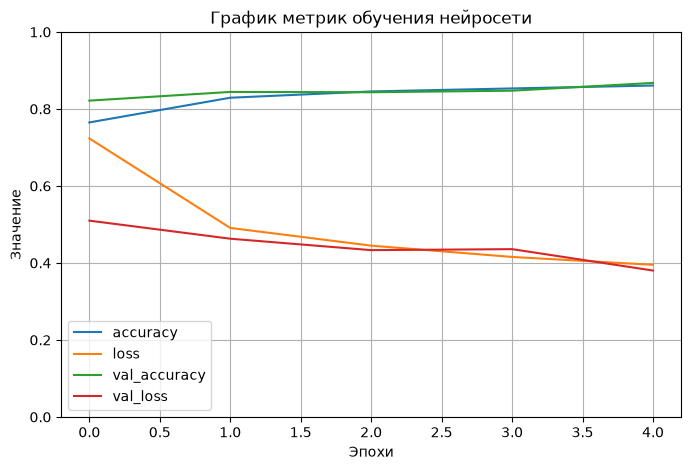

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

Матрица вероятностей для 3-х картинок (результат Softmax):
 [[0.   0.   0.   0.   0.   0.09 0.   0.25 0.   0.65]
 [0.   0.   0.98 0.   0.01 0.   0.01 0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

Предсказанные классы (индексы): [9 2 1]
Предсказанные названия: ['Ботильоны', 'Пуловер', 'Брюки']


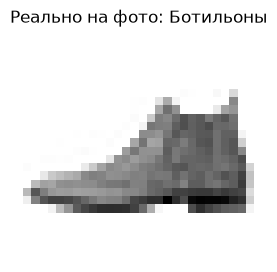

In [4]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("График метрик обучения нейросети")
plt.xlabel("Эпохи")
plt.ylabel("Значение")
plt.show()

X_new = X_test[:3]

y_proba = model.predict(X_new)
print("\nМатрица вероятностей для 3-х картинок (результат Softmax):\n", y_proba.round(2))

y_pred = np.argmax(y_proba, axis=1)
print(f"\nПредсказанные классы (индексы): {y_pred}")
print(f"Предсказанные названия: {[class_names[idx] for idx in y_pred]}")

plt.figure(figsize=(3, 3))
plt.imshow(X_new[0], cmap="binary")
plt.title(f"Реально на фото: {class_names[y_test[0]]}")
plt.axis("off")
plt.show()

In [5]:
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

model_reg = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])

model_reg.compile(loss="mean_squared_error", optimizer="sgd")

print("Запуск обучения регрессионной нейросети...")
history_reg = model_reg.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

mse_test = model_reg.evaluate(X_test, y_test)
print(f"\nФинальная ошибка MSE на тестовых данных: {mse_test:.4f}")

Запуск обучения регрессионной нейросети...
Epoch 1/10


/usr/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8276 - val_loss: 22.6230
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6481 - val_loss: 9.2987
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4882 - val_loss: 2.5053
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4370 - val_loss: 0.3886
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4124 - val_loss: 0.3820
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4006 - val_loss: 0.3836
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3944 - val_loss: 0.3812
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3885 - val_loss: 0.3849
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3836 - val_loss: 0.3888
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3799 - val_loss: 0.3837
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3734

Финальная ошибка MSE на тестовых данных: 0.3734


In [7]:
input_ = keras.layers.Input(shape=X_train.shape[1:])

hidden1 = keras.layers.Dense(30, activation='relu')(input_)
hidden2 = keras.layers.Dense(30, activation='relu')(hidden1)

concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model_functional = keras.models.Model(inputs = [input_], outputs = [output])

model_functional.summary()

model_functional.compile(loss='mean_squared_error', optimizer=keras.optimizers.SGD(learning_rate=1e-3))

print('Обучения нейронки...')
history_func = model_functional.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30)        │        270 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30)        │        930 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,239 (4.84 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

Обучения нейронки...
Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.8114 - val_loss: 0.8901
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7143 - val_loss: 0.6509
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6584 - val_loss: 0.7659
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6317 - val_loss: 0.5854
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6017 - val_loss: 0.7043
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5815 - val_loss: 0.5567
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5611 - val_loss: 0.5481
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5455 - val_loss: 0.5047
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5306 - val_loss: 0.4945
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5176 - val_loss: 0.6249


In [11]:
tf.random.set_seed(42)

class WideAndDeepModel(keras.Model):
    def __init__(self, units = 30, activation = 'relu', **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.conct = keras.layers.Concatenate()

    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = self.conct([input_A, hidden2])
        output = self.main_output(concat)
        return output

model_subclass = WideAndDeepModel(units = 30)

model_subclass.compile(loss='mean_squared_error', optimizer=keras.optimizers.SGD(learning_rate=1e-3))

print('Обучение кастомной модели...')
history_sub = model_subclass.fit((X_train, X_train), y_train, epochs = 5, validation_data=((X_valid, X_valid), y_valid))

Обучение кастомной модели...
Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.5033 - val_loss: 3.8667
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7214 - val_loss: 0.6336
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6221 - val_loss: 0.5837
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5921 - val_loss: 0.5563
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5699 - val_loss: 0.5347


In [12]:
model_reg.save('my_california_model.keras')
print("Модель успешно сохранена в файл 'my_california_model.keras'!")

loaded_model = keras.models.load_model('my_california_model.keras')
print('Модель загружена!')

predictions = loaded_model.predict(X_test[:3])
print("\nПредсказания цен домов от загруженной модели:")
print(predictions.ravel())
print("Реальные цены домов для сравнения:")
print(y_test[:3])

Модель успешно сохранена в файл 'my_california_model.keras'!
Модель загружена!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

Предсказания цен домов от загруженной модели:
[0.7930137 1.717972  3.675157 ]
Реальные цены домов для сравнения:
[0.477   0.458   5.00001]


In [13]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)

print("Запуск обучения с автоматическим сохранением лучшей модели...")
history_with_cb = model_reg.fit(
    X_train, y_train, 
    epochs=10, 
    validation_data=(X_valid, y_valid),
    callbacks=[checkpoint_cb]
)

best_model = keras.models.load_model("best_model.keras")
print("\nУра! Самая точная модель сохранена и готова к работе.")

Запуск обучения с автоматическим сохранением лучшей модели...
Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3755 - val_loss: 0.3841
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3723 - val_loss: 0.3812
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3696 - val_loss: 0.3786
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3672 - val_loss: 0.3761
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3651 - val_loss: 0.3766
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3633 - val_loss: 0.3766
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3616 - val_loss: 0.3745
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3600 - val_loss: 0.3734
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3584 - val_loss: 0.3706
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3571 - val_loss: 0.3687

Ура! Самая точная модель сохранена и готова к работе.
